# NeuroSeek-MoE Training Visualization

This notebook visualizes training progress, loss curves, and evaluation metrics (BERTScore) from the training logs.

## Features:
- Loss curves over epochs
- BERTScore tracking
- Training metrics comparison
- Metric computation explanation


In [1]:
import json
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Add parent directory to path for imports
sys.path.append(str(Path.cwd().parent))

# Enable interactive plots
%matplotlib inline

print("✅ Imports loaded successfully")


✅ Imports loaded successfully


## 1. Load Training Results


In [2]:
# Load final results
results_path = "../evaluation/results.json"

if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        results = json.load(f)
    print("✅ Loaded training results")
    print(f"   Final Loss: {results.get('final_loss', 'N/A')}")
    print(f"   Final BLEU: {results.get('final_bleu', 'N/A')}")
    print(f"   Final BERTScore: {results.get('final_bertscore', 'N/A')}")
    print(f"   Device: {results.get('device', 'N/A')}")
    print(f"   Epochs: {results.get('epochs', 'N/A')}")
else:
    print(f"⚠️  Results file not found: {results_path}")
    results = {}


✅ Loaded training results
   Final Loss: 5.071662156530135
   Final BLEU: 1.0000000000000004
   Final BERTScore: 0.9999999006589254
   Device: cpu
   Epochs: 30


## 2. Load Checkpoint Metrics

Load checkpoint data from either:
- Single training run: `checkpoints/` directory
- Expert comparison: `checkpoints/config_*/` subdirectories


In [3]:
import torch
import glob

# Load metrics from all checkpoints
checkpoint_base_dir = "../checkpoints"
epochs = []
train_losses = []
train_bleu_scores = []
train_bert_scores = []
test_losses = []
test_bleu_scores = []
test_bert_scores = []

# First, check if we have expert comparison subdirectories
config_dirs = []
if os.path.exists(checkpoint_base_dir):
    # Check for config subdirectories (e.g., checkpoints/config_1expert/)
    all_items = os.listdir(checkpoint_base_dir)
    for item in all_items:
        item_path = os.path.join(checkpoint_base_dir, item)
        if os.path.isdir(item_path) and item.startswith("config_"):
            config_dirs.append(item_path)
    
    if config_dirs:
        # Expert comparison mode: load from subdirectories
        print(f"📁 Found {len(config_dirs)} expert configuration directories")
        for config_dir in sorted(config_dirs):
            config_name = os.path.basename(config_dir)
            checkpoint_files = sorted([
                f for f in os.listdir(config_dir) 
                if f.startswith("model_epoch_") and f.endswith(".pt")
            ])
            
            for checkpoint_file in checkpoint_files:
                checkpoint_path = os.path.join(config_dir, checkpoint_file)
                try:
                    checkpoint = torch.load(checkpoint_path, map_location='cpu')
                    epochs.append(checkpoint.get('epoch', 0))
                    train_losses.append(checkpoint.get('loss', 0.0))
                    train_bleu_scores.append(checkpoint.get('bleu', 0.0))
                    train_bert_scores.append(checkpoint.get('bertscore', 0.0))
                    test_losses.append(checkpoint.get('test_loss', 0.0))
                    test_bleu_scores.append(checkpoint.get('test_bleu', 0.0))
                    test_bert_scores.append(checkpoint.get('test_bertscore', 0.0))
                except Exception as e:
                    print(f"⚠️  Failed to load {config_name}/{checkpoint_file}: {e}")
                    continue
    else:
        # Single training run: load from base directory
        checkpoint_files = sorted([
            f for f in os.listdir(checkpoint_base_dir) 
            if f.startswith("model_epoch_") and f.endswith(".pt")
        ])
        
        for checkpoint_file in checkpoint_files:
            checkpoint_path = os.path.join(checkpoint_base_dir, checkpoint_file)
            try:
                checkpoint = torch.load(checkpoint_path, map_location='cpu')
                epochs.append(checkpoint.get('epoch', 0))
                train_losses.append(checkpoint.get('loss', 0.0))
                train_bleu_scores.append(checkpoint.get('bleu', 0.0))
                train_bert_scores.append(checkpoint.get('bertscore', 0.0))
                test_losses.append(checkpoint.get('test_loss', 0.0))
                test_bleu_scores.append(checkpoint.get('test_bleu', 0.0))
                test_bert_scores.append(checkpoint.get('test_bertscore', 0.0))
            except Exception as e:
                print(f"⚠️  Failed to load {checkpoint_file}: {e}")
                continue

if epochs:
    print(f"✅ Loaded {len(epochs)} checkpoints")
    print(f"   Epoch range: {min(epochs)} to {max(epochs)}")
    print(f"   Train Loss range: {min(train_losses):.4f} to {max(train_losses):.4f}")
    print(f"   Test Loss range: {min(test_losses):.4f} to {max(test_losses):.4f}")
else:
    if os.path.exists(checkpoint_base_dir):
        print(f"⚠️  No checkpoint files found in {checkpoint_base_dir}")
    else:
        print(f"⚠️  Checkpoint directory not found: {checkpoint_base_dir}")


📁 Found 10 expert configuration directories
✅ Loaded 240 checkpoints
   Epoch range: 1 to 50
   Train Loss range: 3.1104 to 10.9604
   Test Loss range: 7.5272 to 25.6108


## 3. Plot Training Curves


✅ Saved training curves to training_curves.png
   Note: Test metrics are used for model selection in expert comparison


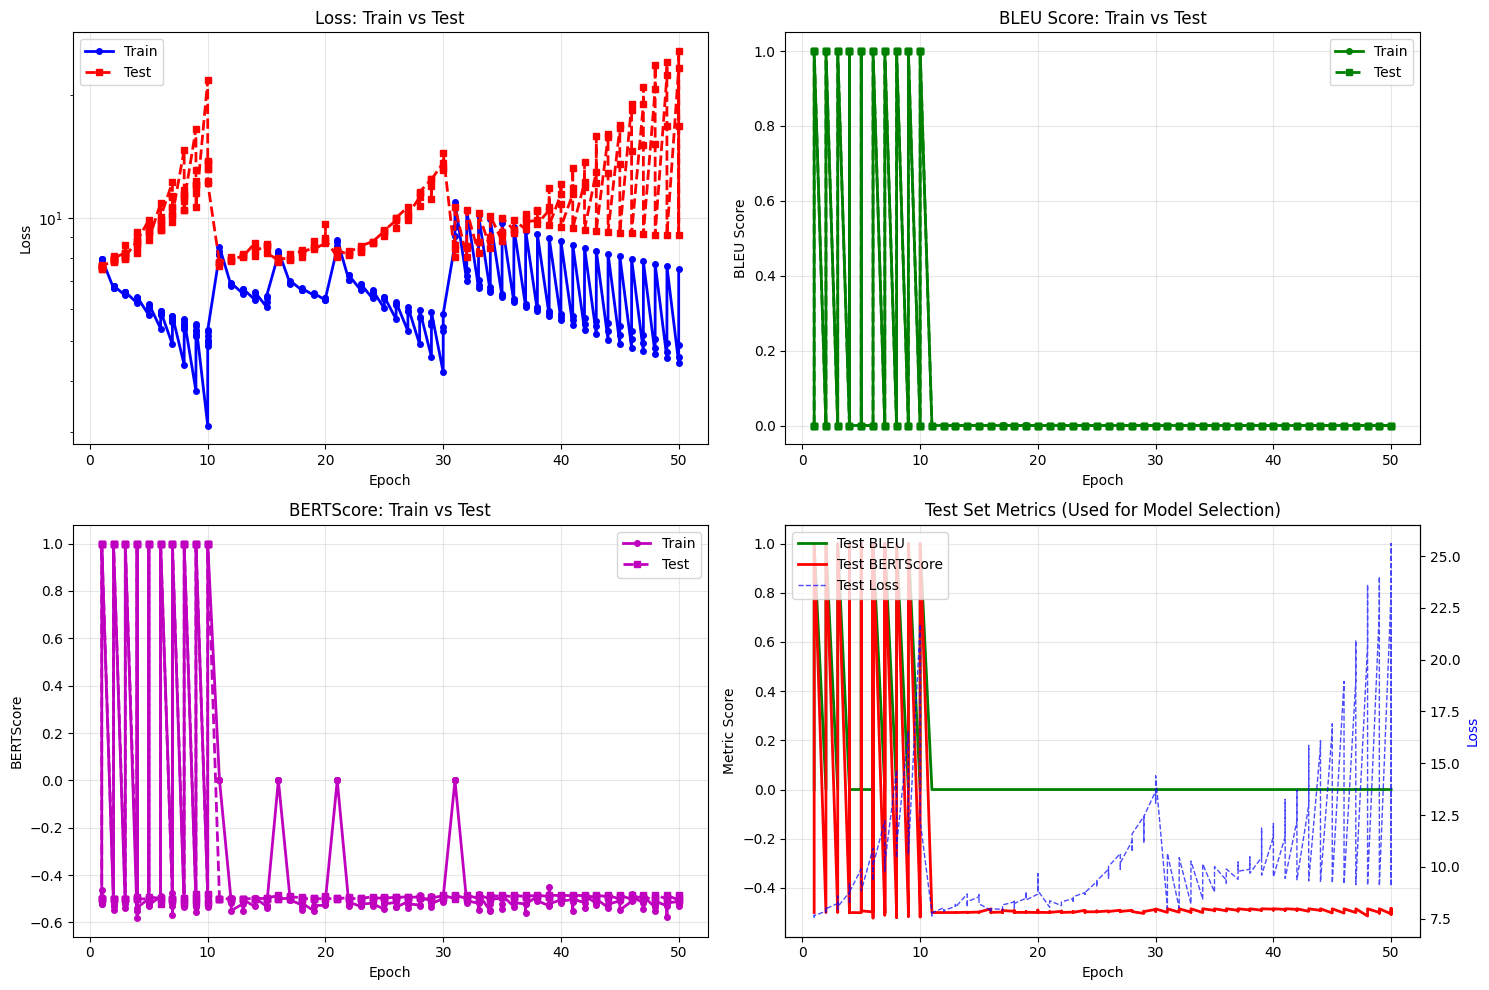

In [4]:
if epochs and train_losses:
    # Sort by epoch
    sorted_data = sorted(zip(epochs, train_losses, train_bleu_scores, train_bert_scores, 
                            test_losses, test_bleu_scores, test_bert_scores))
    epochs_sorted, train_losses_sorted, train_bleu_sorted, train_bert_sorted, \
    test_losses_sorted, test_bleu_sorted, test_bert_sorted = zip(*sorted_data)
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss curve (train vs test)
    axes[0, 0].plot(epochs_sorted, train_losses_sorted, 'b-', linewidth=2, marker='o', markersize=4, label='Train')
    axes[0, 0].plot(epochs_sorted, test_losses_sorted, 'r--', linewidth=2, marker='s', markersize=4, label='Test')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Loss: Train vs Test')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_yscale('log')  # Log scale for better visualization
    axes[0, 0].legend()
    
    # BLEU score (train vs test)
    if any(train_bleu_sorted) or any(test_bleu_sorted):
        if any(train_bleu_sorted):
            axes[0, 1].plot(epochs_sorted, train_bleu_sorted, 'g-', linewidth=2, marker='o', markersize=4, label='Train')
        if any(test_bleu_sorted):
            axes[0, 1].plot(epochs_sorted, test_bleu_sorted, 'g--', linewidth=2, marker='s', markersize=4, label='Test')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('BLEU Score')
        axes[0, 1].set_title('BLEU Score: Train vs Test')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].legend()
    else:
        axes[0, 1].text(0.5, 0.5, 'No BLEU data available', 
                       ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('BLEU Score Over Time')
    
    # BERTScore (train vs test)
    if any(train_bert_sorted) or any(test_bert_sorted):
        if any(train_bert_sorted):
            axes[1, 0].plot(epochs_sorted, train_bert_sorted, 'm-', linewidth=2, marker='o', markersize=4, label='Train')
        if any(test_bert_sorted):
            axes[1, 0].plot(epochs_sorted, test_bert_sorted, 'm--', linewidth=2, marker='s', markersize=4, label='Test')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('BERTScore')
        axes[1, 0].set_title('BERTScore: Train vs Test')
        axes[1, 0].grid(True, alpha=0.3)
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'No BERTScore data available', 
                       ha='center', va='center', transform=axes[1, 0].transAxes)
        axes[1, 0].set_title('BERTScore Over Time')
    
    # Combined metrics (test set focus)
    ax_combined = axes[1, 1]
    ax_loss = ax_combined.twinx()
    
    lines = []
    labels = []
    
    if any(test_bleu_sorted):
        line1 = ax_combined.plot(epochs_sorted, test_bleu_sorted, 'g-', label='Test BLEU', linewidth=2)
        lines.extend(line1)
        labels.append('Test BLEU')
    
    if any(test_bert_sorted):
        line2 = ax_combined.plot(epochs_sorted, test_bert_sorted, 'r-', label='Test BERTScore', linewidth=2)
        lines.extend(line2)
        labels.append('Test BERTScore')
    
    line3 = ax_loss.plot(epochs_sorted, test_losses_sorted, 'b--', label='Test Loss', linewidth=1, alpha=0.7)
    lines.extend(line3)
    labels.append('Test Loss')
    
    ax_combined.set_xlabel('Epoch')
    ax_combined.set_ylabel('Metric Score', color='black')
    ax_loss.set_ylabel('Loss', color='blue')
    ax_combined.set_title('Test Set Metrics (Used for Model Selection)')
    ax_combined.grid(True, alpha=0.3)
    
    # Combined legend
    ax_combined.legend(lines, labels, loc='upper left')
    
    plt.tight_layout()
    plt.savefig('../training_curves.png', dpi=150, bbox_inches='tight')
    print("✅ Saved training curves to training_curves.png")
    print("   Note: Test metrics are used for model selection in expert comparison")
    plt.show()
else:
    print("⚠️  No checkpoint data available for plotting")


## 7.5. Per-Configuration Loss Curves

Visualize loss progression across epochs for **each expert configuration separately**. This is useful when comparing multiple configurations trained with `compare_expert_configs.py`.


📊 Plotting loss curves for 10 configurations separately

   ✅ 1expert: 50 checkpoints (epochs 1-50)
   ✅ 1multi: 50 checkpoints (epochs 1-50)
   ✅ 1text+1image: 10 checkpoints (epochs 1-10)
   ✅ 1text+1image+1multi: 50 checkpoints (epochs 1-50)
   ✅ 2expert: 10 checkpoints (epochs 1-10)
   ✅ 3expert: 10 checkpoints (epochs 1-10)
   ✅ 4expert: 10 checkpoints (epochs 1-10)
   ✅ unknown: 50 checkpoints (epochs 1-50)

✅ Saved per-configuration loss curves to per_config_loss_curves.png
   Showing loss progression for 8 configurations


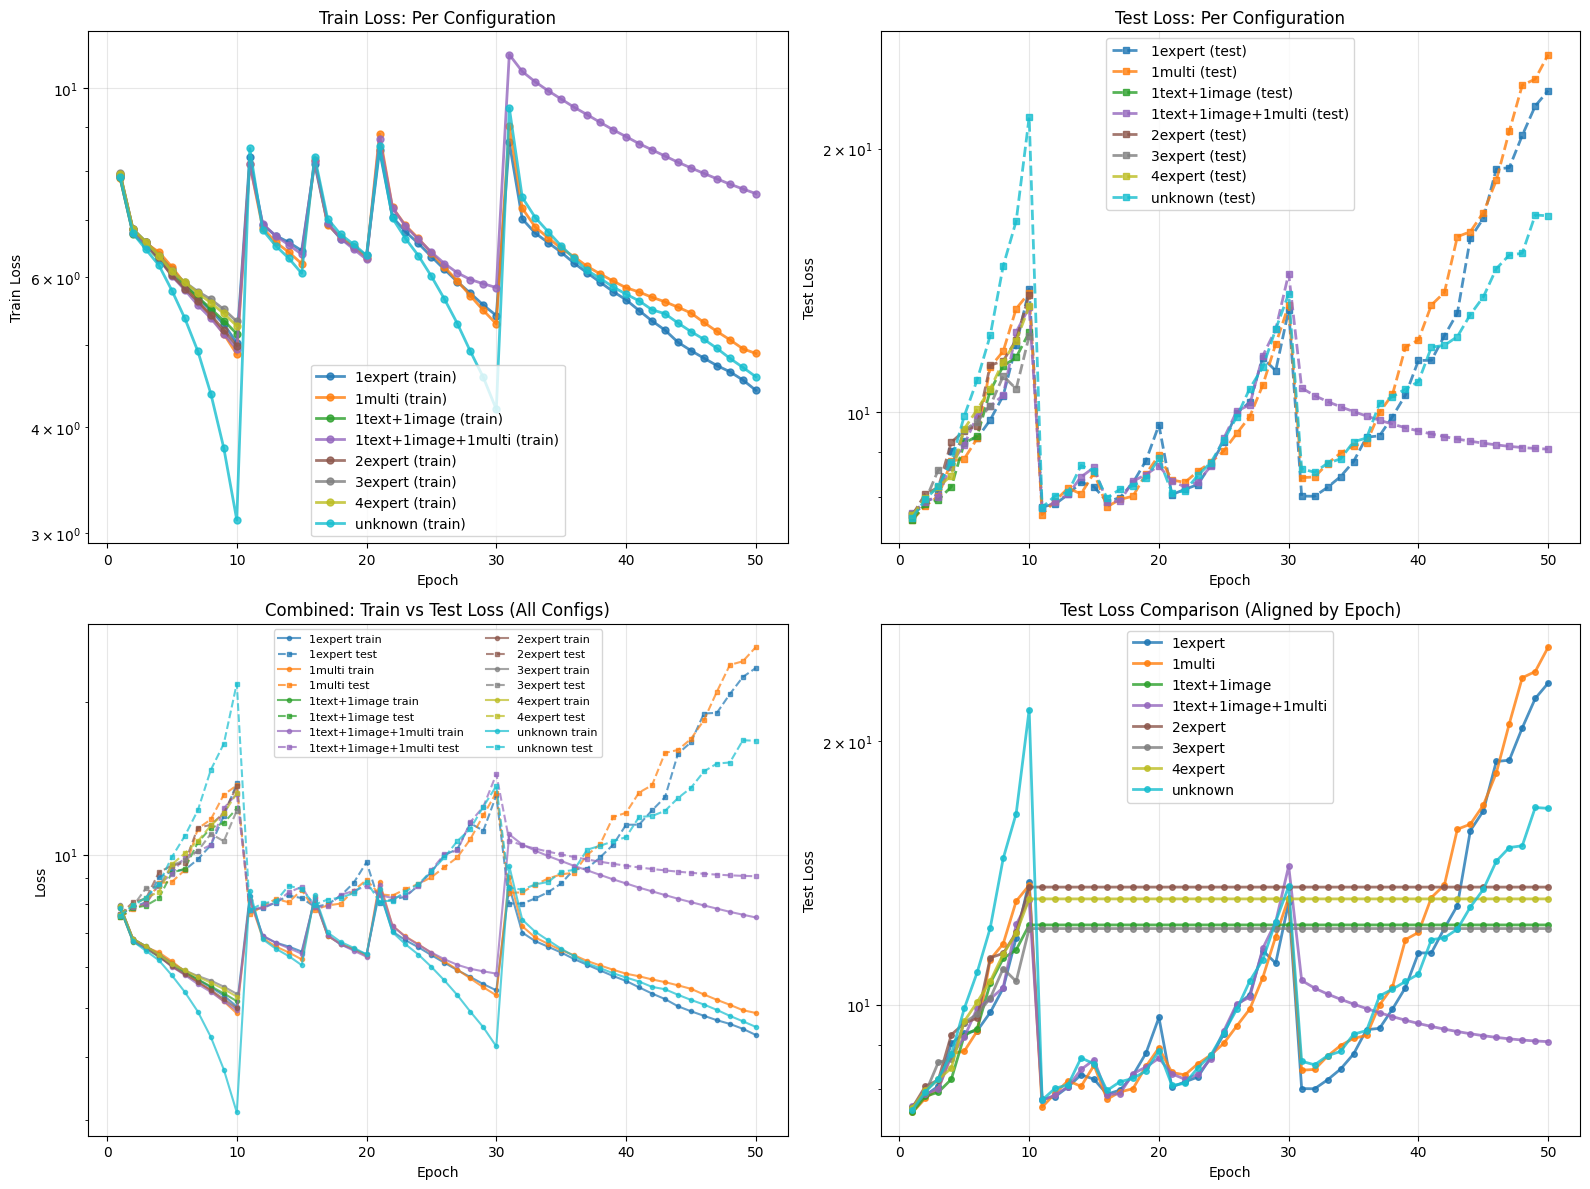

In [5]:
# Load checkpoints per configuration and plot separate curves
checkpoint_base_dir = "../checkpoints"
config_dirs = []

if os.path.exists(checkpoint_base_dir):
    # Find all config subdirectories
    all_items = os.listdir(checkpoint_base_dir)
    for item in all_items:
        item_path = os.path.join(checkpoint_base_dir, item)
        if os.path.isdir(item_path) and item.startswith("config_"):
            config_dirs.append(item_path)

if config_dirs and len(config_dirs) > 1:
    # We have multiple configurations - plot separately
    print(f"📊 Plotting loss curves for {len(config_dirs)} configurations separately\n")
    
    # Store data per configuration
    config_data = {}
    
    for config_dir in sorted(config_dirs):
        config_name = os.path.basename(config_dir).replace("config_", "")
        checkpoint_files = sorted([
            f for f in os.listdir(config_dir) 
            if f.startswith("model_epoch_") and f.endswith(".pt")
        ])
        
        epochs_list = []
        train_losses_list = []
        test_losses_list = []
        train_bleu_list = []
        test_bleu_list = []
        train_bert_list = []
        test_bert_list = []
        
        for checkpoint_file in checkpoint_files:
            checkpoint_path = os.path.join(config_dir, checkpoint_file)
            try:
                checkpoint = torch.load(checkpoint_path, map_location='cpu')
                epochs_list.append(checkpoint.get('epoch', 0))
                train_losses_list.append(checkpoint.get('loss', 0.0))
                test_losses_list.append(checkpoint.get('test_loss', 0.0))
                train_bleu_list.append(checkpoint.get('bleu', 0.0))
                test_bleu_list.append(checkpoint.get('test_bleu', 0.0))
                train_bert_list.append(checkpoint.get('bertscore', 0.0))
                test_bert_list.append(checkpoint.get('test_bertscore', 0.0))
            except Exception as e:
                continue
        
        if epochs_list:
            # Sort by epoch
            sorted_indices = sorted(range(len(epochs_list)), key=lambda i: epochs_list[i])
            config_data[config_name] = {
                'epochs': [epochs_list[i] for i in sorted_indices],
                'train_losses': [train_losses_list[i] for i in sorted_indices],
                'test_losses': [test_losses_list[i] for i in sorted_indices],
                'train_bleu': [train_bleu_list[i] for i in sorted_indices],
                'test_bleu': [test_bleu_list[i] for i in sorted_indices],
                'train_bert': [train_bert_list[i] for i in sorted_indices],
                'test_bert': [test_bert_list[i] for i in sorted_indices],
            }
            print(f"   ✅ {config_name}: {len(epochs_list)} checkpoints (epochs {min(epochs_list)}-{max(epochs_list)})")
    
    if config_data:
        # Plot separate curves for each configuration
        import matplotlib.pyplot as plt
        import numpy as np
        
        # Create color map for configurations
        colors = plt.cm.tab10(np.linspace(0, 1, len(config_data)))
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Train Loss across epochs for each config
        ax1 = axes[0, 0]
        for idx, (config_name, data) in enumerate(config_data.items()):
            ax1.plot(data['epochs'], data['train_losses'], 
                    'o-', linewidth=2, markersize=5, 
                    color=colors[idx], label=f'{config_name} (train)', alpha=0.8)
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Train Loss')
        ax1.set_title('Train Loss: Per Configuration')
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)
        ax1.set_yscale('log')
        
        # 2. Test Loss across epochs for each config
        ax2 = axes[0, 1]
        for idx, (config_name, data) in enumerate(config_data.items()):
            ax2.plot(data['epochs'], data['test_losses'], 
                    's--', linewidth=2, markersize=5, 
                    color=colors[idx], label=f'{config_name} (test)', alpha=0.8)
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Test Loss')
        ax2.set_title('Test Loss: Per Configuration')
        ax2.legend(loc='best')
        ax2.grid(True, alpha=0.3)
        ax2.set_yscale('log')
        
        # 3. Combined Train vs Test Loss for each config (subplot per config)
        ax3 = axes[1, 0]
        for idx, (config_name, data) in enumerate(config_data.items()):
            ax3.plot(data['epochs'], data['train_losses'], 
                    'o-', linewidth=1.5, markersize=3, 
                    color=colors[idx], label=f'{config_name} train', alpha=0.7)
            ax3.plot(data['epochs'], data['test_losses'], 
                    's--', linewidth=1.5, markersize=3, 
                    color=colors[idx], label=f'{config_name} test', alpha=0.7)
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Loss')
        ax3.set_title('Combined: Train vs Test Loss (All Configs)')
        ax3.legend(loc='best', ncol=2, fontsize=8)
        ax3.grid(True, alpha=0.3)
        ax3.set_yscale('log')
        
        # 4. Test Loss comparison (highlight best per epoch)
        ax4 = axes[1, 1]
        all_epochs = set()
        for data in config_data.values():
            all_epochs.update(data['epochs'])
        all_epochs = sorted(all_epochs)
        
        # Interpolate test losses for each config at all epochs
        for idx, (config_name, data) in enumerate(config_data.items()):
            interpolated_losses = np.interp(all_epochs, data['epochs'], data['test_losses'])
            ax4.plot(all_epochs, interpolated_losses, 
                    'o-', linewidth=2, markersize=4, 
                    color=colors[idx], label=config_name, alpha=0.8)
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Test Loss')
        ax4.set_title('Test Loss Comparison (Aligned by Epoch)')
        ax4.legend(loc='best')
        ax4.grid(True, alpha=0.3)
        ax4.set_yscale('log')
        
        plt.tight_layout()
        plt.savefig('../per_config_loss_curves.png', dpi=150, bbox_inches='tight')
        print(f"\n✅ Saved per-configuration loss curves to per_config_loss_curves.png")
        print(f"   Showing loss progression for {len(config_data)} configurations")
        plt.show()
    else:
        print("⚠️  No checkpoint data found for any configuration")
elif config_dirs and len(config_dirs) == 1:
    print("ℹ️  Only one configuration found. Use the main training curves section above.")
elif not config_dirs:
    print("ℹ️  No configuration subdirectories found. Use the main training curves section above.")


In [6]:
print("📊 How BLEU and BERTScore are Computed:")
print("\n" + "="*60)
print("BLEU (Bilingual Evaluation Understudy):")
print("  - Measures n-gram overlap between predicted and reference text")
print("  - Range: 0.0 (no overlap) to 1.0 (perfect match)")
print("  - Uses sacrebleu library for standardized computation")
print("  - Computed every 100 batches during training")
print("\nBERTScore:")
print("  - Uses BERT embeddings to measure semantic similarity")
print("  - More robust to synonyms and paraphrasing than BLEU")
print("  - Range: Typically -1.0 to 1.0 (with rescaling)")
print("  - Uses bert-score library with RoBERTa model")
print("  - Model is cached to avoid repeated loading")
print("\n" + "="*60)
print("\n⚠️  NOTE: Current implementation uses reference text as hypothesis")
print("   (placeholder until text decoder is implemented)")
print("   Real metrics would compare actual model predictions to references")
print("\n💡 Tip: Metrics are logged to TensorBoard for real-time monitoring")


📊 How BLEU and BERTScore are Computed:

BLEU (Bilingual Evaluation Understudy):
  - Measures n-gram overlap between predicted and reference text
  - Range: 0.0 (no overlap) to 1.0 (perfect match)
  - Uses sacrebleu library for standardized computation
  - Computed every 100 batches during training

BERTScore:
  - Uses BERT embeddings to measure semantic similarity
  - More robust to synonyms and paraphrasing than BLEU
  - Range: Typically -1.0 to 1.0 (with rescaling)
  - Uses bert-score library with RoBERTa model
  - Model is cached to avoid repeated loading


⚠️  NOTE: Current implementation uses reference text as hypothesis
   (placeholder until text decoder is implemented)
   Real metrics would compare actual model predictions to references

💡 Tip: Metrics are logged to TensorBoard for real-time monitoring


## 5. Training Statistics


In [7]:
if epochs and train_losses:
    sorted_data = sorted(zip(epochs, train_losses, train_bleu_scores, train_bert_scores,
                            test_losses, test_bleu_scores, test_bert_scores))
    epochs_sorted, train_losses_sorted, train_bleu_sorted, train_bert_sorted, \
    test_losses_sorted, test_bleu_sorted, test_bert_sorted = zip(*sorted_data)
    
    print("📈 Training Statistics:")
    print(f"\n   Total Epochs: {len(epochs)}")
    print(f"   Epoch Range: {min(epochs_sorted)} - {max(epochs_sorted)}")
    
    print(f"\n   Train Loss:")
    print(f"     Initial: {train_losses_sorted[0]:.4f}")
    print(f"     Final: {train_losses_sorted[-1]:.4f}")
    print(f"     Improvement: {(train_losses_sorted[0] - train_losses_sorted[-1]):.4f}")
    
    print(f"\n   Test Loss (used for selection):")
    print(f"     Initial: {test_losses_sorted[0]:.4f}")
    print(f"     Final: {test_losses_sorted[-1]:.4f}")
    print(f"     Improvement: {(test_losses_sorted[0] - test_losses_sorted[-1]):.4f}")
    best_test_loss_idx = test_losses_sorted.index(min(test_losses_sorted))
    print(f"     Best: {min(test_losses_sorted):.4f} (epoch {epochs_sorted[best_test_loss_idx]})")
    
    if any(test_bleu_sorted):
        print(f"\n   Test BLEU (used for selection):")
        print(f"     First: {test_bleu_sorted[0]:.4f}")
        print(f"     Final: {test_bleu_sorted[-1]:.4f}")
        best_test_bleu_idx = test_bleu_sorted.index(max(test_bleu_sorted))
        print(f"     Best: {max(test_bleu_sorted):.4f} (epoch {epochs_sorted[best_test_bleu_idx]})")
    else:
        print(f"\n   Test BLEU: No data available")
    
    if any(test_bert_sorted):
        print(f"\n   Test BERTScore (used for selection):")
        print(f"     First: {test_bert_sorted[0]:.4f}")
        print(f"     Final: {test_bert_sorted[-1]:.4f}")
        best_test_bert_idx = test_bert_sorted.index(max(test_bert_sorted))
        print(f"     Best: {max(test_bert_sorted):.4f} (epoch {epochs_sorted[best_test_bert_idx]})")
    else:
        print(f"\n   Test BERTScore: No data available")
    
    # Show overfitting indicator
    if len(test_losses_sorted) > 0 and len(train_losses_sorted) > 0:
        final_gap = train_losses_sorted[-1] - test_losses_sorted[-1]
        initial_gap = train_losses_sorted[0] - test_losses_sorted[0]
        gap_change = final_gap - initial_gap
        
        print(f"\n   Overfitting Check (Loss-based):")
        if final_gap < 0:
            print(f"     ✅ Test loss lower than train loss (good generalization)")
        elif final_gap < 1.0:
            print(f"     ✅ Small gap ({final_gap:.4f}) - good generalization")
        else:
            print(f"     ⚠️  Large gap ({final_gap:.4f}) - possible overfitting")
        
        # Check for overfitting signs
        if len(test_losses_sorted) > 1:
            test_loss_change = test_losses_sorted[-1] - test_losses_sorted[0]
            train_loss_change = train_losses_sorted[-1] - train_losses_sorted[0]
            if test_loss_change > 1.0 and train_loss_change < -0.5:
                print(f"     ⚠️  WARNING: Test loss increasing ({test_loss_change:+.4f}) while train decreases ({train_loss_change:+.4f})")
                print(f"     ⚠️  This indicates OVERFITTING - model is memorizing training data")
                print(f"     💡 Consider: Early stopping, regularization, or reducing model capacity")
    
    # Warn about placeholder BLEU/BERTScore metrics
    if any(test_bleu_sorted) and all(score == 1.0 for score in test_bleu_sorted):
        print(f"\n   ⚠️  BLEU/BERTScore Warning:")
        print(f"     These scores are PLACEHOLDERS (always 1.0)")
        print(f"     The code compares reference text to itself instead of model predictions")
        print(f"     See train_real.py line 498: 'hyp_text = ref_text  # Placeholder'")
        print(f"     💡 Focus on LOSS metrics for real training progress")
        print(f"     💡 To get real BLEU/BERTScore, implement a text decoder (token IDs → text)")
else:
    print("⚠️  No checkpoint data available for statistics")


📈 Training Statistics:

   Total Epochs: 240
   Epoch Range: 1 - 50

   Train Loss:
     Initial: 7.8505
     Final: 7.5236
     Improvement: 0.3269

   Test Loss (used for selection):
     Initial: 7.5272
     Final: 9.0690
     Improvement: -1.5418
     Best: 7.5272 (epoch 1)

   Test BLEU (used for selection):
     First: 0.0000
     Final: 0.0000
     Best: 1.0000 (epoch 1)

   Test BERTScore (used for selection):
     First: -0.5002
     Final: -0.4848
     Best: 1.0000 (epoch 1)

   Overfitting Check (Loss-based):
     ✅ Test loss lower than train loss (good generalization)


## 6. Training Metrics Explanation

Understanding where and how metrics are stored during training.


In [8]:
print("📊 Training Metrics Storage:")
print("\nMetrics are saved in two places:")
print("\n1. Checkpoint Files (checkpoints/):")
print("   - Each checkpoint (model_epoch_N.pt) contains:")
print("     • Model weights")
print("     • Optimizer state")
print("     • Epoch number")
print("     • Average loss for that epoch")
print("     • BLEU score (if computed)")
print("     • BERTScore (if computed)")
print("\n2. Results JSON (evaluation/results.json):")
print("   - Final training summary:")
print("     • Total epochs")
print("     • Final loss")
print("     • Final BLEU and BERTScore")
print("     • Device used")
print("     • Model path")
print("\n💡 Tip: Use this notebook to visualize metrics from checkpoints")
print("   and compare training progress across epochs.")


📊 Training Metrics Storage:

Metrics are saved in two places:

1. Checkpoint Files (checkpoints/):
   - Each checkpoint (model_epoch_N.pt) contains:
     • Model weights
     • Optimizer state
     • Epoch number
     • Average loss for that epoch
     • BLEU score (if computed)
     • BERTScore (if computed)

2. Results JSON (evaluation/results.json):
   - Final training summary:
     • Total epochs
     • Final loss
     • Final BLEU and BERTScore
     • Device used
     • Model path

💡 Tip: Use this notebook to visualize metrics from checkpoints
   and compare training progress across epochs.


## 8. Expert Configuration Comparison Visualization

Load and visualize results from expert configuration comparison (`compare_expert_configs.py`).


In [9]:
# Load expert comparison results
comparison_path = "../evaluation/expert_comparison.json"
best_config_path = "../evaluation/best_config.json"
outputs_base_dir = "../outputs"
checkpoints_base_dir = "../checkpoints"

comparison_data = None
best_config_data = None

# Try loading from comparison file first
if os.path.exists(comparison_path):
    with open(comparison_path, 'r') as f:
        comparison_data = json.load(f)
    print("✅ Loaded expert comparison results from JSON")
    print(f"   Configurations tested: {len(comparison_data.get('all_configs', []))}")
    print(f"   Best config: {comparison_data.get('best_config_name', 'N/A')}")
    print(f"   Selection metric: {comparison_data.get('selection_metric', 'N/A')}")
else:
    print(f"⚠️  Comparison file not found: {comparison_path}")
    print("   Attempting to load from individual config result files...")
    
    # Fallback: Load from individual config result files in subdirectories
    if os.path.exists(outputs_base_dir):
        config_result_files = glob.glob(os.path.join(outputs_base_dir, "config_*_results.json"))
        if config_result_files:
            print(f"   Found {len(config_result_files)} individual config result files")
            all_configs = []
            for result_file in sorted(config_result_files):
                try:
                    with open(result_file, 'r') as f:
                        config_data = json.load(f)
                        all_configs.append(config_data)
                        config_name = os.path.basename(result_file).replace("_results.json", "").replace("config_", "")
                        print(f"     - {config_name}: Experts={config_data.get('num_experts', 'N/A')}")
                except Exception as e:
                    print(f"     ⚠️  Failed to load {result_file}: {e}")
            
            if all_configs:
                # Determine best config (lowest test loss by default)
                best_config = min(all_configs, key=lambda x: x.get('test_loss', x.get('final_loss', float('inf'))))
                comparison_data = {
                    "all_configs": all_configs,
                    "best_config": best_config,
                    "best_config_name": best_config.get('config_name', 'unknown'),
                    "selection_metric": "loss",
                    "expert_configs_tested": [c.get('num_experts', 0) for c in all_configs]
                }
                print(f"   ✅ Reconstructed comparison from {len(all_configs)} config files")
                print(f"   Best config: {comparison_data['best_config_name']}")
            else:
                print("   ⚠️  Could not load any config results")
    else:
        print("   Run compare_expert_configs.py first to generate comparison data")

if os.path.exists(best_config_path):
    with open(best_config_path, 'r') as f:
        best_config_data = json.load(f)
    print(f"\n✅ Loaded best configuration info")
    print(f"   Best config: {best_config_data.get('config_name', 'N/A')}")
    print(f"   Experts: {best_config_data.get('num_experts', 'N/A')} per modality")
else:
    print(f"\n⚠️  Best config file not found: {best_config_path}")
    if comparison_data:
        print(f"   Using best config from comparison data: {comparison_data.get('best_config_name', 'N/A')}")


✅ Loaded expert comparison results from JSON
   Configurations tested: 4
   Best config: 1text+1image+1multi
   Selection metric: combined

✅ Loaded best configuration info
   Best config: 1text+1image+1multi
   Experts: N/A per modality


\n✅ Saved expert configuration comparison to expert_config_comparison.png
   Best configuration highlighted in gold: 1text+1image+1multi


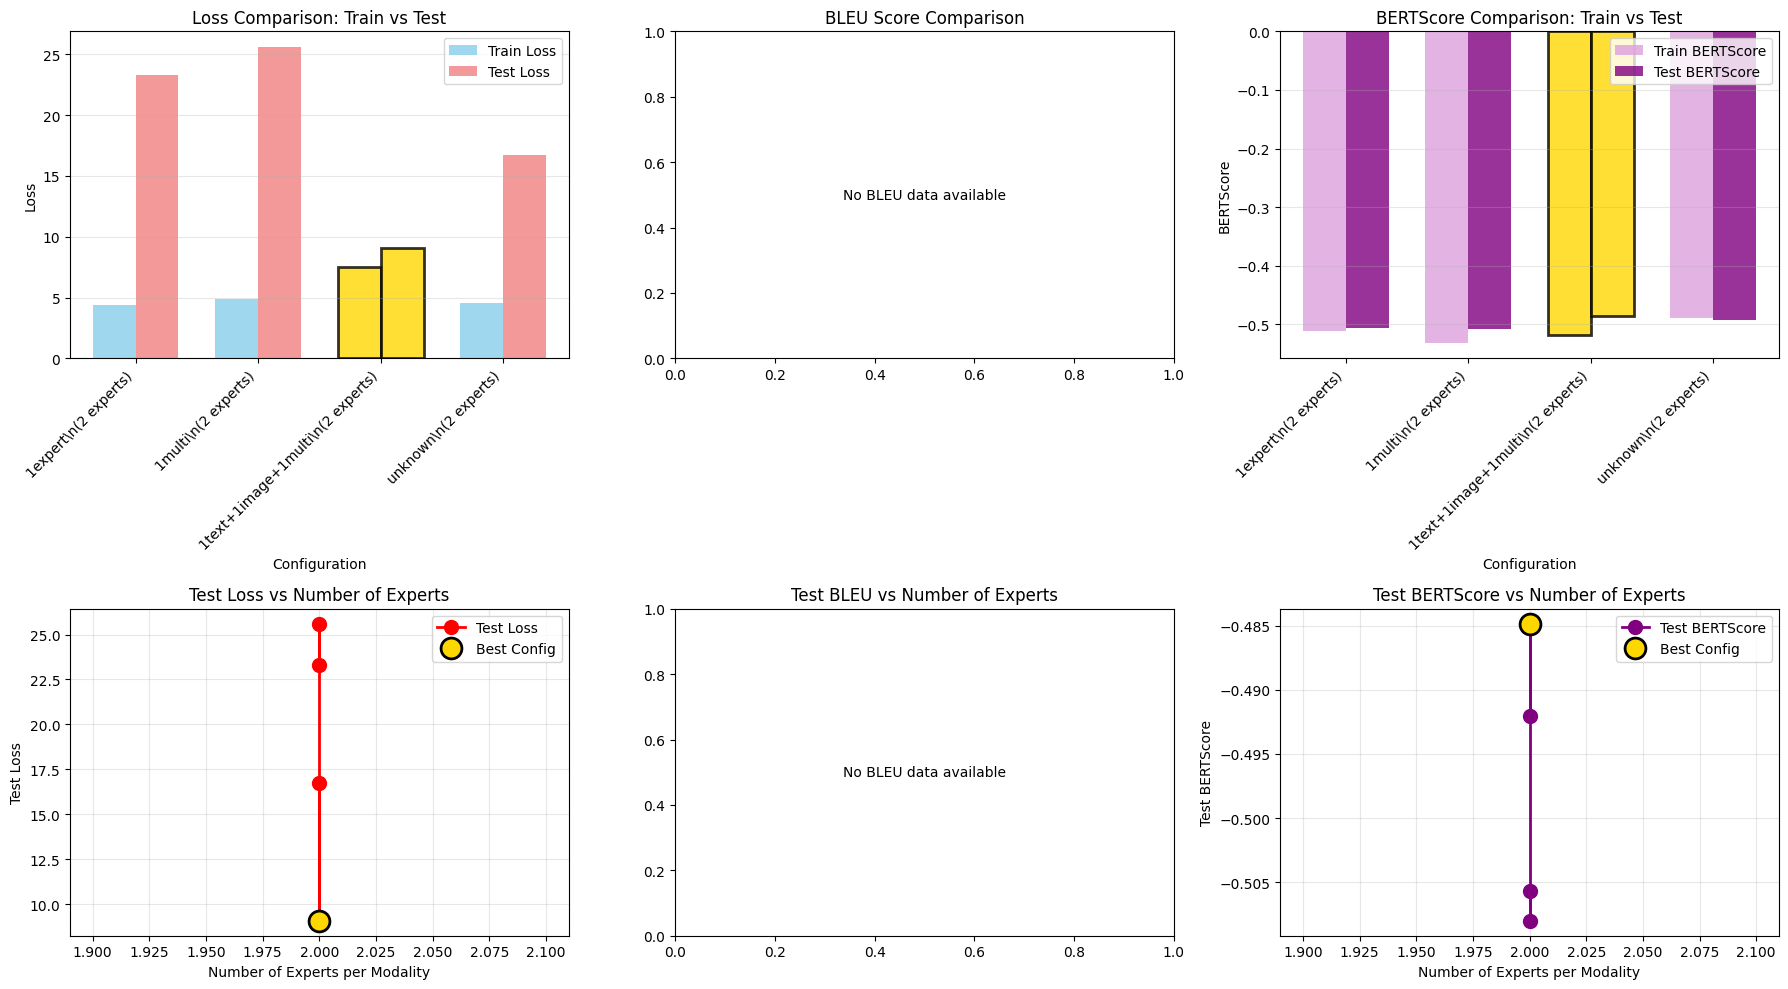

In [10]:
# Visualize expert configuration comparison
if comparison_data and comparison_data.get('all_configs'):
    configs = comparison_data['all_configs']
    best_name = comparison_data.get('best_config_name', '')
    
    # Extract metrics
    config_names = []
    num_experts = []
    train_losses = []
    test_losses = []
    train_bleu = []
    test_bleu = []
    train_bert = []
    test_bert = []
    
    for cfg in configs:
        config_names.append(cfg.get('config_name', 'unknown'))
        num_experts.append(cfg.get('num_experts', 0))
        train_losses.append(cfg.get('final_loss', 0))
        test_losses.append(cfg.get('test_loss', 0))
        train_bleu.append(cfg.get('final_bleu', 0))
        test_bleu.append(cfg.get('test_bleu', 0))
        train_bert.append(cfg.get('final_bertscore', 0))
        test_bert.append(cfg.get('test_bertscore', 0))
    
    # Create comprehensive comparison visualization
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    x_pos = np.arange(len(config_names))
    best_idx = config_names.index(best_name) if best_name in config_names else -1
    
    # 1. Loss comparison (Train vs Test)
    ax1 = axes[0, 0]
    width = 0.35
    bars1 = ax1.bar(x_pos - width/2, train_losses, width, label='Train Loss', color='skyblue', alpha=0.8)
    bars2 = ax1.bar(x_pos + width/2, test_losses, width, label='Test Loss', color='lightcoral', alpha=0.8)
    if best_idx >= 0:
        bars1[best_idx].set_color('gold')
        bars2[best_idx].set_color('gold')
        bars1[best_idx].set_edgecolor('black')
        bars2[best_idx].set_edgecolor('black')
        bars1[best_idx].set_linewidth(2)
        bars2[best_idx].set_linewidth(2)
    ax1.set_xlabel('Configuration')
    ax1.set_ylabel('Loss')
    ax1.set_title('Loss Comparison: Train vs Test')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f"{name}\\n({exp} experts)" for name, exp in zip(config_names, num_experts)], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # 2. BLEU comparison
    ax2 = axes[0, 1]
    if any(test_bleu) or any(train_bleu):
        bars3 = ax2.bar(x_pos - width/2, train_bleu, width, label='Train BLEU', color='lightgreen', alpha=0.8)
        bars4 = ax2.bar(x_pos + width/2, test_bleu, width, label='Test BLEU', color='darkgreen', alpha=0.8)
        if best_idx >= 0:
            bars3[best_idx].set_color('gold')
            bars4[best_idx].set_color('gold')
            bars3[best_idx].set_edgecolor('black')
            bars4[best_idx].set_edgecolor('black')
            bars3[best_idx].set_linewidth(2)
            bars4[best_idx].set_linewidth(2)
        ax2.set_xlabel('Configuration')
        ax2.set_ylabel('BLEU Score')
        ax2.set_title('BLEU Score Comparison: Train vs Test')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([f"{name}\\n({exp} experts)" for name, exp in zip(config_names, num_experts)], rotation=45, ha='right')
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')
    else:
        ax2.text(0.5, 0.5, 'No BLEU data available', ha='center', va='center', transform=ax2.transAxes)
        ax2.set_title('BLEU Score Comparison')
    
    # 3. BERTScore comparison
    ax3 = axes[0, 2]
    if any(test_bert) or any(train_bert):
        bars5 = ax3.bar(x_pos - width/2, train_bert, width, label='Train BERTScore', color='plum', alpha=0.8)
        bars6 = ax3.bar(x_pos + width/2, test_bert, width, label='Test BERTScore', color='purple', alpha=0.8)
        if best_idx >= 0:
            bars5[best_idx].set_color('gold')
            bars6[best_idx].set_color('gold')
            bars5[best_idx].set_edgecolor('black')
            bars6[best_idx].set_edgecolor('black')
            bars5[best_idx].set_linewidth(2)
            bars6[best_idx].set_linewidth(2)
        ax3.set_xlabel('Configuration')
        ax3.set_ylabel('BERTScore')
        ax3.set_title('BERTScore Comparison: Train vs Test')
        ax3.set_xticks(x_pos)
        ax3.set_xticklabels([f"{name}\\n({exp} experts)" for name, exp in zip(config_names, num_experts)], rotation=45, ha='right')
        ax3.legend()
        ax3.grid(True, alpha=0.3, axis='y')
    else:
        ax3.text(0.5, 0.5, 'No BERTScore data available', ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('BERTScore Comparison')
    
    # 4. Test Loss by Number of Experts
    ax4 = axes[1, 0]
    ax4.plot(num_experts, test_losses, 'o-', linewidth=2, markersize=10, color='red', label='Test Loss')
    if best_idx >= 0:
        ax4.plot(num_experts[best_idx], test_losses[best_idx], 'o', markersize=15, color='gold', 
                markeredgecolor='black', markeredgewidth=2, label='Best Config')
    ax4.set_xlabel('Number of Experts per Modality')
    ax4.set_ylabel('Test Loss')
    ax4.set_title('Test Loss vs Number of Experts')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    # 5. Test BLEU by Number of Experts
    ax5 = axes[1, 1]
    if any(test_bleu):
        ax5.plot(num_experts, test_bleu, 'o-', linewidth=2, markersize=10, color='green', label='Test BLEU')
        if best_idx >= 0:
            ax5.plot(num_experts[best_idx], test_bleu[best_idx], 'o', markersize=15, color='gold',
                    markeredgecolor='black', markeredgewidth=2, label='Best Config')
        ax5.set_xlabel('Number of Experts per Modality')
        ax5.set_ylabel('Test BLEU Score')
        ax5.set_title('Test BLEU vs Number of Experts')
        ax5.grid(True, alpha=0.3)
        ax5.legend()
    else:
        ax5.text(0.5, 0.5, 'No BLEU data available', ha='center', va='center', transform=ax5.transAxes)
        ax5.set_title('Test BLEU vs Number of Experts')
    
    # 6. Test BERTScore by Number of Experts
    ax6 = axes[1, 2]
    if any(test_bert):
        ax6.plot(num_experts, test_bert, 'o-', linewidth=2, markersize=10, color='purple', label='Test BERTScore')
        if best_idx >= 0:
            ax6.plot(num_experts[best_idx], test_bert[best_idx], 'o', markersize=15, color='gold',
                    markeredgecolor='black', markeredgewidth=2, label='Best Config')
        ax6.set_xlabel('Number of Experts per Modality')
        ax6.set_ylabel('Test BERTScore')
        ax6.set_title('Test BERTScore vs Number of Experts')
        ax6.grid(True, alpha=0.3)
        ax6.legend()
    else:
        ax6.text(0.5, 0.5, 'No BERTScore data available', ha='center', va='center', transform=ax6.transAxes)
        ax6.set_title('Test BERTScore vs Number of Experts')
    
    plt.tight_layout()
    plt.savefig('../expert_config_comparison.png', dpi=150, bbox_inches='tight')
    print("\\n✅ Saved expert configuration comparison to expert_config_comparison.png")
    print(f"   Best configuration highlighted in gold: {best_name}")
    plt.show()
else:
    print("⚠️  No comparison data available. Run compare_expert_configs.py first.")


In [11]:
# Create detailed comparison table
if comparison_data and comparison_data.get('all_configs'):
    import pandas as pd
    
    configs = comparison_data['all_configs']
    
    # Prepare data for DataFrame
    table_data = []
    for cfg in configs:
        row = {
            'Config': cfg.get('config_name', 'unknown'),
            'Experts': cfg.get('num_experts', 0),
            'Train Loss': f"{cfg.get('final_loss', 0):.4f}",
            'Test Loss': f"{cfg.get('test_loss', 0):.4f}",
            'Train BLEU': f"{cfg.get('final_bleu', 0):.4f}",
            'Test BLEU': f"{cfg.get('test_bleu', 0):.4f}",
            'Train BERT': f"{cfg.get('final_bertscore', 0):.4f}",
            'Test BERT': f"{cfg.get('test_bertscore', 0):.4f}",
            'Training Time (min)': f"{cfg.get('training_time', 0) / 60:.2f}",
        }
        if cfg.get('config_name') == comparison_data.get('best_config_name'):
            row['Best'] = '⭐'
        else:
            row['Best'] = ''
        table_data.append(row)
    
    df = pd.DataFrame(table_data)
    print("\\n📊 Expert Configuration Comparison Table:")
    print("="*100)
    print(df.to_string(index=False))
    print("="*100)
    
    # Highlight key insights
    if best_config_data:
        best_metrics = best_config_data.get('metrics', {})
        print(f"\\n🏆 Best Configuration Summary:")
        print(f"   Name: {best_config_data.get('config_name')}")
        print(f"   Experts: {best_config_data.get('num_experts')} per modality")
        print(f"   Test Loss: {best_metrics.get('test_loss', 'N/A')}")
        print(f"   Test BLEU: {best_metrics.get('test_bleu', 'N/A')}")
        print(f"   Test BERTScore: {best_metrics.get('test_bertscore', 'N/A')}")
        print(f"\\n💡 This configuration is automatically used in evaluation.ipynb")
else:
    print("⚠️  No comparison data to display")


\n📊 Expert Configuration Comparison Table:
             Config  Experts Train Loss Test Loss Train BLEU Test BLEU Train BERT Test BERT Training Time (min) Best
            1expert        2     4.4183   23.2987     0.0000    0.0000    -0.5109   -0.5057               14.55     
             1multi        2     4.8813   25.6108     0.0000    0.0000    -0.5313   -0.5080               16.41     
1text+1image+1multi        2     7.5236    9.0690     0.0000    0.0000    -0.5182   -0.4848               16.51    ⭐
            unknown        2     4.5829   16.7549     0.0000    0.0000    -0.4895   -0.4920               12.46     
\n🏆 Best Configuration Summary:
   Name: 1text+1image+1multi
   Experts: None per modality
   Test Loss: 9.069031862417857
   Test BLEU: 0.0
   Test BERTScore: -0.4848277270793915
\n💡 This configuration is automatically used in evaluation.ipynb


In [12]:
# Analyze expert configuration trends
if comparison_data and comparison_data.get('all_configs'):
    configs = comparison_data['all_configs']
    
    # Sort by number of experts
    sorted_configs = sorted(configs, key=lambda x: x.get('num_experts', 0))
    
    num_experts_list = [c.get('num_experts', 0) for c in sorted_configs]
    test_losses_list = [c.get('test_loss', 0) for c in sorted_configs]
    test_bleu_list = [c.get('test_bleu', 0) for c in sorted_configs]
    test_bert_list = [c.get('test_bertscore', 0) for c in sorted_configs]
    
    print("📈 Expert Configuration Analysis:")
    print("\\n" + "="*70)
    
    # Find optimal number of experts
    if test_losses_list:
        best_loss_idx = test_losses_list.index(min(test_losses_list))
        best_loss_config = sorted_configs[best_loss_idx]
        print(f"\\n🎯 Best Test Loss:")
        print(f"   Configuration: {best_loss_config.get('config_name')}")
        print(f"   Number of Experts: {best_loss_config.get('num_experts')}")
        print(f"   Test Loss: {best_loss_config.get('test_loss', 0):.4f}")
    
    if any(test_bleu_list):
        best_bleu_idx = test_bleu_list.index(max(test_bleu_list))
        best_bleu_config = sorted_configs[best_bleu_idx]
        print(f"\\n🎯 Best Test BLEU:")
        print(f"   Configuration: {best_bleu_config.get('config_name')}")
        print(f"   Number of Experts: {best_bleu_config.get('num_experts')}")
        print(f"   Test BLEU: {best_bleu_config.get('test_bleu', 0):.4f}")
    
    if any(test_bert_list):
        best_bert_idx = test_bert_list.index(max(test_bert_list))
        best_bert_config = sorted_configs[best_bert_idx]
        print(f"\\n🎯 Best Test BERTScore:")
        print(f"   Configuration: {best_bert_config.get('config_name')}")
        print(f"   Number of Experts: {best_bert_config.get('num_experts')}")
        print(f"   Test BERTScore: {best_bert_config.get('test_bertscore', 0):.4f}")
    
    # Analyze scaling trends
    print(f"\\n📊 Scaling Analysis:")
    if len(num_experts_list) > 1:
        # Calculate improvement per additional expert
        improvements = []
        for i in range(1, len(test_losses_list)):
            if test_losses_list[i-1] > 0:
                improvement = ((test_losses_list[i-1] - test_losses_list[i]) / test_losses_list[i-1]) * 100
                improvements.append(improvement)
                print(f"   {num_experts_list[i-1]} → {num_experts_list[i]} experts: "
                      f"Loss change: {improvement:+.2f}%")
        
        # Detect if more experts help or hurt
        if improvements:
            avg_improvement = sum(improvements) / len(improvements)
            if avg_improvement > 0:
                print(f"\\n   ✅ Adding experts generally improves performance (avg {avg_improvement:.2f}% better)")
            else:
                print(f"\\n   ⚠️  Adding experts doesn't consistently improve performance")
    
    # Overfitting analysis
    print(f"\\n🔍 Overfitting Analysis:")
    for cfg in sorted_configs:
        train_loss = cfg.get('final_loss', 0)
        test_loss = cfg.get('test_loss', 0)
        if train_loss > 0 and test_loss > 0:
            gap = train_loss - test_loss
            gap_pct = (gap / train_loss) * 100 if train_loss > 0 else 0
            config_name = cfg.get('config_name', 'unknown')
            if gap < 0:
                status = "✅ Good generalization"
            elif gap < 1.0:
                status = "✅ Small gap"
            else:
                status = "⚠️  Possible overfitting"
            print(f"   {config_name}: gap={gap:.4f} ({gap_pct:+.1f}%) - {status}")
    
    print("\\n" + "="*70)
else:
    print("⚠️  No comparison data available for analysis")


📈 Expert Configuration Analysis:
\n======================================================================
\n🎯 Best Test Loss:
   Configuration: 1text+1image+1multi
   Number of Experts: 2
   Test Loss: 9.0690
\n🎯 Best Test BERTScore:
   Configuration: 1text+1image+1multi
   Number of Experts: 2
   Test BERTScore: -0.4848
\n📊 Scaling Analysis:
   2 → 2 experts: Loss change: -9.92%
   2 → 2 experts: Loss change: +64.59%
   2 → 2 experts: Loss change: -84.75%
\n   ⚠️  Adding experts doesn't consistently improve performance
\n🔍 Overfitting Analysis:
   1expert: gap=-18.8804 (-427.3%) - ✅ Good generalization
   1multi: gap=-20.7295 (-424.7%) - ✅ Good generalization
   1text+1image+1multi: gap=-1.5454 (-20.5%) - ✅ Good generalization
   unknown: gap=-12.1719 (-265.6%) - ✅ Good generalization
\n======================================================================


## 7. Real-Time Metric Example

Here's how metrics are computed during training (simplified example):


In [13]:
# Example of how metrics are computed during training
def demonstrate_metric_computation():
    """Shows how BLEU and BERTScore are computed during training."""
    
    # Example reference and hypothesis texts
    reference = "Alzheimer's disease involves amyloid plaque formation in the brain."
    hypothesis = "Alzheimer's disease is characterized by amyloid beta plaques in neural tissue."
    
    print("📝 Example Metric Computation:")
    print(f"\n   Reference:  {reference}")
    print(f"   Hypothesis: {hypothesis}")
    
    # BLEU computation (simplified)
    try:
        from sacrebleu import sentence_bleu
        bleu_score = sentence_bleu(hypothesis, [reference]).score / 100.0
        print(f"\n   BLEU Score: {bleu_score:.4f}")
        print(f"   (Range: 0.0 = no overlap, 1.0 = perfect match)")
    except ImportError:
        print(f"\n   BLEU Score: (sacrebleu not installed)")
    
    # BERTScore computation (simplified)
    try:
        from bert_score import score as bert_score_fn
        P, R, F1 = bert_score_fn([hypothesis], [reference], lang="en", rescale_with_baseline=True)
        bert_score = float(F1.mean())
        print(f"   BERTScore:  {bert_score:.4f}")
        print(f"   (Range: typically -1.0 to 1.0, higher = more similar)")
    except ImportError:
        print(f"   BERTScore:  (bert-score not installed)")
    
    print(f"\n💡 During training:")
    print(f"   - Metrics computed every 100 batches")
    print(f"   - Up to 3 samples per batch evaluated")
    print(f"   - Results logged to TensorBoard and checkpoints")
    print(f"   - BERTScore model is cached to avoid reloading")

demonstrate_metric_computation()


📝 Example Metric Computation:

   Reference:  Alzheimer's disease involves amyloid plaque formation in the brain.
   Hypothesis: Alzheimer's disease is characterized by amyloid beta plaques in neural tissue.

   BLEU Score: 0.0852
   (Range: 0.0 = no overlap, 1.0 = perfect match)


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   BERTScore:  0.7270
   (Range: typically -1.0 to 1.0, higher = more similar)

💡 During training:
   - Metrics computed every 100 batches
   - Up to 3 samples per batch evaluated
   - Results logged to TensorBoard and checkpoints
   - BERTScore model is cached to avoid reloading
